
## Predicción del Mercado de Valores con Numerai

In [261]:
%pip install pandas numpy matplotlib seaborn scikit-learn jupyterlab # type: ignore

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [262]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [263]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from scipy import stats
from numerapi import NumerAPI
import lightgbm as lgb
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, LinearRegression
import xgboost as xgb
import cloudpickle
from datetime import datetime

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)

# 1. DATASET - Exploración y Preprocesamiento

## 1.1 Descarga de Datos

In [264]:
# Descargar datos
import os

train_file = f"{DATA_VERSION}/train.parquet"
features_file = f"{DATA_VERSION}/features.json"

In [265]:
# Cargar metadata de features
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]

print("📊 Conjuntos de features disponibles:")
for feature_set_name in ["small", "medium", "all"]:
    features = feature_sets[feature_set_name]
    print(f"  - {feature_set_name}: {len(features)} features")

# Usar conjunto 'medium'
feature_set = feature_sets["medium"]
print(f"\nSeleccionado 'medium'")

📊 Conjuntos de features disponibles:
  - small: 42 features
  - medium: 705 features
  - all: 2376 features

Seleccionado 'medium'


In [266]:
# Cargar datos
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

### Reducción del Dataset
1. Solapamiento temporal (targets miran 20 días adelante)
2. Eficiencia computacional
3. Mantener estructura temporal

**Decisión**: Cada 4ª era para que se reduzca sustancialmente el solapamimento

In [267]:
# Reducir dataset - tomando cada 4ª era
eras_antes = train['era'].nunique()
train = train[train["era"].isin(train["era"].unique()[::4])]
eras_despues = train['era'].nunique()

print(f"Eras antes: {eras_antes}")
print(f"Eras después: {eras_despues}")
print(f"Shape final: {train.shape}")

Eras antes: 574
Eras después: 144
Shape final: (688184, 707)


## 1.2 Exploración Inicial

In [268]:
train.info()
print("\nTarget:")
print(train['target'].describe())

<class 'pandas.core.frame.DataFrame'>
Index: 688184 entries, n0007b5abb0c3a25 to nfff87b21e4db902
Columns: 707 entries, era to feature_zymotic_windswept_cooky
dtypes: float32(1), int8(705), object(1)
memory usage: 475.8+ MB

Target:
count    688184.000000
mean          0.500008
std           0.223148
min           0.000000
25%           0.250000
50%           0.500000
75%           0.500000
max           1.000000
Name: target, dtype: float64


In [269]:
# Valores nulos
null_counts = train.isnull().sum()
if null_counts.sum() > 0:
    print("VALORES NULOS ENCONTRADOS:")
    print(null_counts[null_counts > 0])
else:
    print("No hay valores nulos")

No hay valores nulos


## 1.3 Visualizaciones

### 📊 Gráfica 1: Distribución del Target

**Importancia**: Muestra cómo se distribuyen los rendimientos

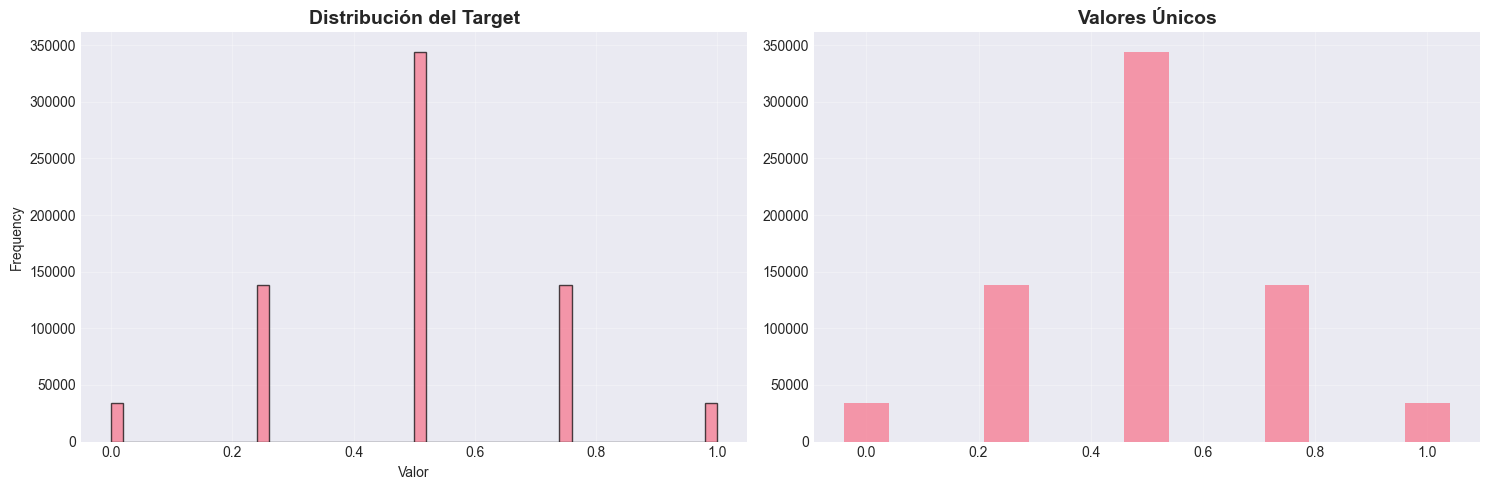

In [270]:
# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train['target'].plot(kind='hist', bins=50, ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución del Target', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Valor')
axes[0].grid(True, alpha=0.3)

target_counts = train['target'].value_counts().sort_index()
axes[1].bar(target_counts.index, target_counts.values, width=0.08, alpha=0.7)
axes[1].set_title('Valores Únicos', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Gráfica 2: Distribución de Eras

Cada era = 1 semana en el mercado

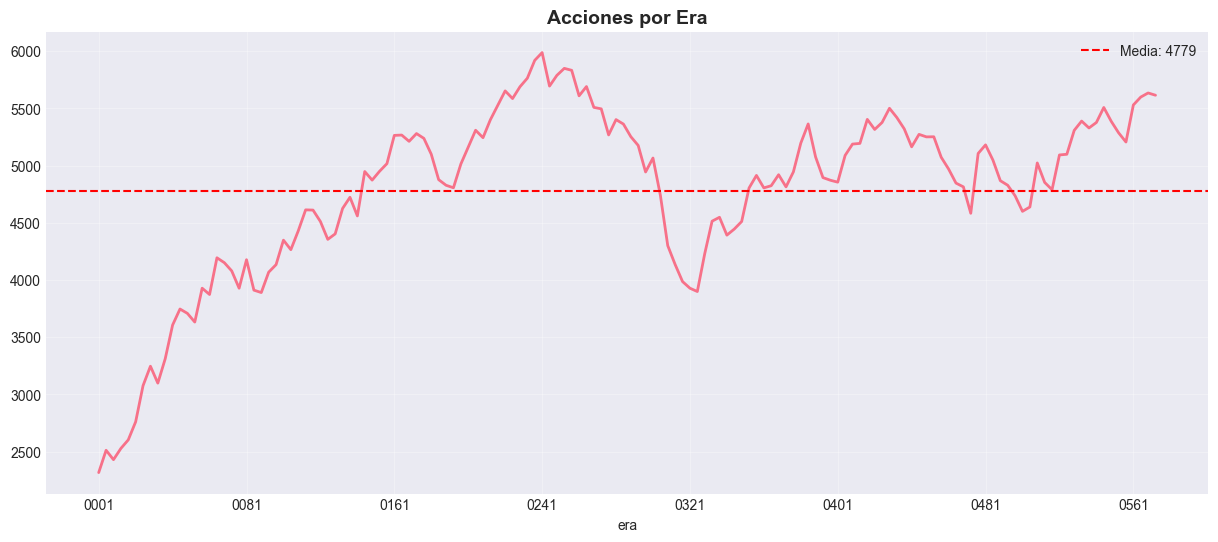

Eras: 144
Media acciones/era: 4779


In [271]:
# Distribución de eras
era_counts = train.groupby('era').size()

plt.figure(figsize=(15, 6))
era_counts.plot(kind='line', linewidth=2)
plt.title('Acciones por Era', fontsize=14, fontweight='bold')
plt.axhline(y=era_counts.mean(), color='r', linestyle='--', label=f'Media: {era_counts.mean():.0f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Eras: {train['era'].nunique()}")
print(f"Media acciones/era: {era_counts.mean():.0f}")

### 📊 Gráfica 3: Correlaciones con Target

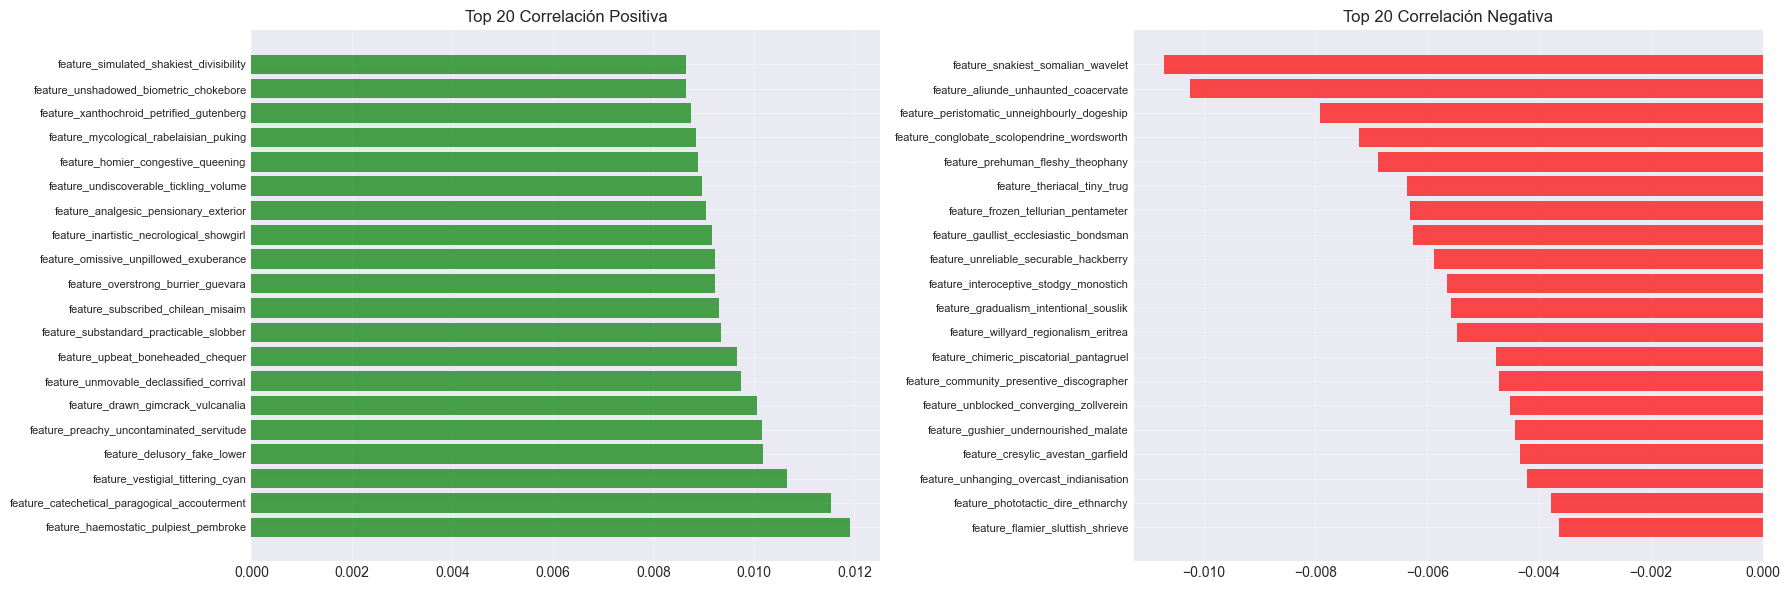


Correlación máxima: 0.0119
Correlación mínima: -0.0107


In [272]:
# Correlaciones
correlations = train[feature_set].corrwith(train['target']).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_positive = correlations.head(20)
top_negative = correlations.tail(20)

axes[0].barh(range(len(top_positive)), top_positive.values, color='green', alpha=0.7)
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive.index, fontsize=8)
axes[0].set_title('Top 20 Correlación Positiva')
axes[0].grid(True, alpha=0.3)

axes[1].barh(range(len(top_negative)), top_negative.values, color='red', alpha=0.7)
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative.index, fontsize=8)
axes[1].set_title('Top 20 Correlación Negativa')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCorrelación máxima: {correlations.max():.4f}")
print(f"Correlación mínima: {correlations.min():.4f}")

## 1.4 Selección de Features

1. Correlación con target
2. Varianza
3. Importancia del modelo

In [273]:
# Método 1: Selección por Correlación con el target
CORRELATION_THRESHOLD = 0.005
selected_by_corr = correlations[correlations.abs() > CORRELATION_THRESHOLD].index.tolist()

print(f"📊 Método 1 - Correlación (>{CORRELATION_THRESHOLD}):")
print(f"Original: {len(feature_set)}")
print(f"Seleccionadas: {len(selected_by_corr)}")
print(f"Reducción: {(1-len(selected_by_corr)/len(feature_set))*100:.1f}%")

📊 Método 1 - Correlación (>0.005):
Original: 705
Seleccionadas: 84
Reducción: 88.1%


In [274]:
# Método 2: Varianza
variances = train[feature_set].var()
VARIANCE_THRESHOLD = 0.01
selected_by_var = variances[variances > VARIANCE_THRESHOLD].index.tolist()

print(f"📊 Método 2 - Varianza (>{VARIANCE_THRESHOLD}):")
print(f"Seleccionadas: {len(selected_by_var)}")
print(f"Reducción: {(1-len(selected_by_var)/len(feature_set))*100:.1f}%")

📊 Método 2 - Varianza (>0.01):
Seleccionadas: 705
Reducción: 0.0%


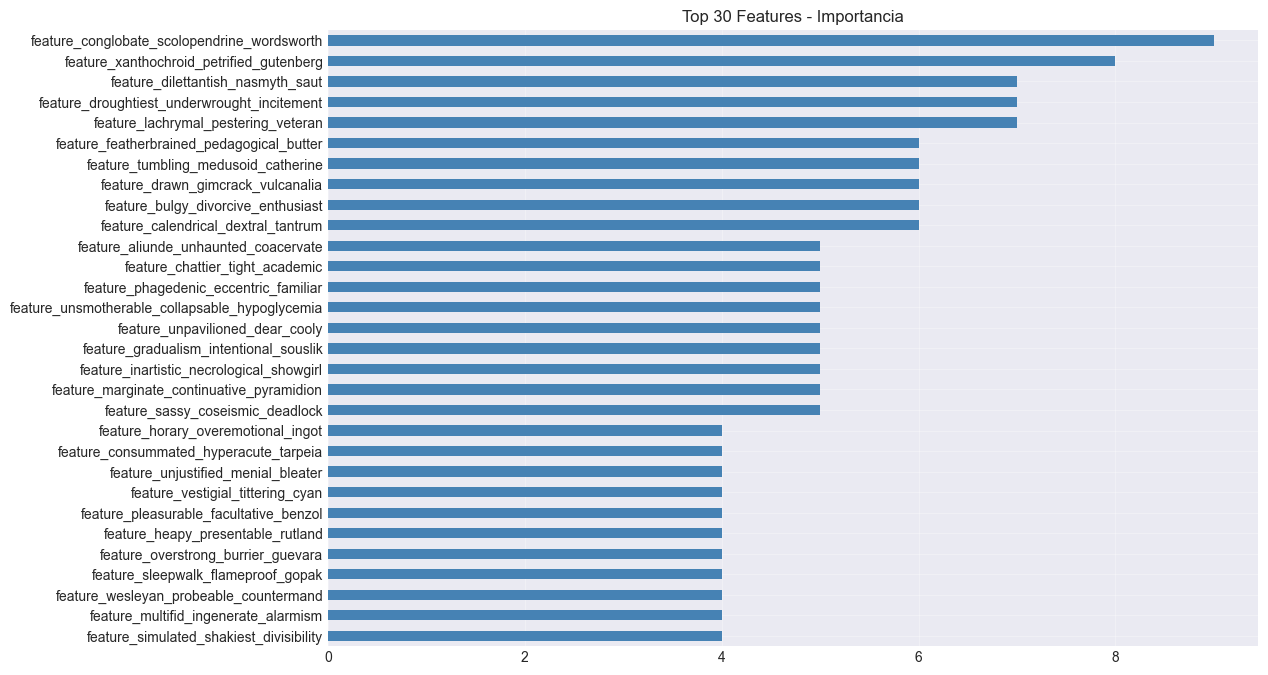


Importancia (top 75%):
Seleccionadas: 351


In [275]:
# Método 3: Importancia del modelo

sample = train.sample(n=min(100000, len(train)), random_state=42)

preliminary_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbose=-1
)

preliminary_model.fit(sample[feature_set], sample['target'])

feature_importance = pd.Series(
    preliminary_model.feature_importances_,
    index=feature_set
).sort_values(ascending=False)

# Visualizar
plt.figure(figsize=(12, 8))
feature_importance.head(30).plot(kind='barh', color='steelblue')
plt.title('Top 30 Features - Importancia')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

threshold = feature_importance.quantile(0.25)
selected_by_importance = feature_importance[feature_importance > threshold].index.tolist()

print(f"\nImportancia (top 75%):")
print(f"Seleccionadas: {len(selected_by_importance)}")

In [276]:
# Combinar métodos
selected_features = list(
    set(selected_by_corr) & 
    set(selected_by_var) & 
    set(selected_by_importance)
)

print(f"\nFEATURES FINALES")
print(f" Original: {len(feature_set)}")
print(f" Seleccionadas: {len(selected_features)}")
print(f" Reducción: {(1-len(selected_features)/len(feature_set))*100:.1f}%")


FEATURES FINALES
 Original: 705
 Seleccionadas: 61
 Reducción: 91.3%


## 1.5 Preprocesamiento: Escalado

**Aplicaremos StandardScaler porque:**
- PCA requiere datos escalados
- Ridge Regression necesita misma escala
- Centra datos en media=0, std=1

In [277]:
# Aplicar StandardScaler
scaler = StandardScaler()
train_scaled = train.copy()
train_scaled[selected_features] = scaler.fit_transform(train[selected_features])

print(f"Escalado completado \nMedia: {train_scaled[selected_features].mean().mean():.6f} \nStd: {train_scaled[selected_features].std().mean():.6f}")

Escalado completado 
Media: 0.000000 
Std: 1.000001


## 1.6 PCA - Reducción de Dimensionalidad con PCA

- Reduce dimensionalidad
- Encuentra combinaciones lineales óptimas
- Reduce multicolinealidad

**Criterio**: 95% varianza explicada

In [278]:
# Aplicar PCA
pca_full = PCA(random_state=42)
pca_full.fit(train_scaled[selected_features])

cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1

print("📊 ANÁLISIS PCA")
print(f"Features originales: {len(selected_features)}")
print(f"Componentes (95%): {n_components_95}")
print(f"Reducción: {(1-n_components_95/len(selected_features))*100:.1f}%")

📊 ANÁLISIS PCA
Features originales: 61
Componentes (95%): 31
Reducción: 49.2%


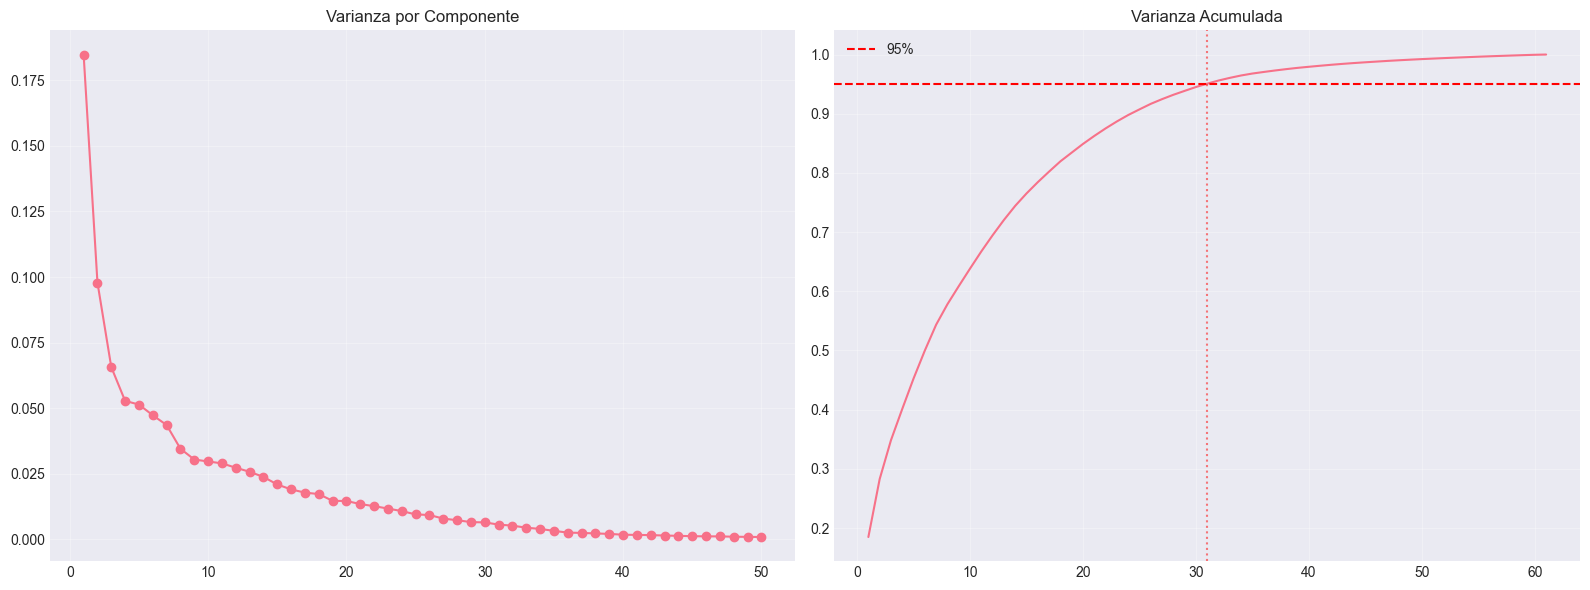

In [279]:
# Visualizar varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(range(1, min(51, len(selected_features)+1)), 
             pca_full.explained_variance_ratio_[:50], 
             marker='o')
axes[0].set_title('Varianza por Componente')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(selected_features)+1), cumsum_var)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95%')
axes[1].axvline(x=n_components_95, color='r', linestyle=':', alpha=0.5)
axes[1].set_title('Varianza Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [280]:
# Aplicar PCA con n óptimo
pca = PCA(n_components=n_components_95, random_state=42)
train_pca = pca.fit_transform(train_scaled[selected_features])

pca_columns = [f'PC{i+1}' for i in range(n_components_95)]
train_pca_df = pd.DataFrame(train_pca, columns=pca_columns, index=train.index)
train_pca_df['era'] = train['era']
train_pca_df['target'] = train['target']

print(f"PCA aplicado: {n_components_95} componentes")

PCA aplicado: 31 componentes


## 1.7 Comparación: Original vs PCA

In [281]:
# Función de evaluación
def practica_corr(preds, target):
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    centered_target = target - target.mean()
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    return np.corrcoef(preds_p15, target_p15)[0, 1]

print("\n📊 PASO 1: COMPARACIÓN FEATURES ORIGINALES vs PCA")

# Comparar Original vs PCA
indices = np.random.choice(train.index, min(200000, len(train)), replace=False)

# Modelo 1: Features originales
model_orig = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
model_orig.fit(train_scaled.loc[indices, selected_features], train.loc[indices, 'target'])
preds_orig = model_orig.predict(train_scaled.loc[indices, selected_features])
corr_orig = practica_corr(pd.Series(preds_orig), train.loc[indices, 'target'])
print(f"  Correlación Features Originales: {corr_orig:.6f}")

# Modelo 2: PCA
model_pca = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
model_pca.fit(train_pca_df.loc[indices, pca_columns], train.loc[indices, 'target'])
preds_pca = model_pca.predict(train_pca_df.loc[indices, pca_columns])
corr_pca = practica_corr(pd.Series(preds_pca), train.loc[indices, 'target'])
print(f"  Correlación PCA: {corr_pca:.6f}")

# Decisión
diff = ((corr_pca - corr_orig) / abs(corr_orig)) * 100
USE_PCA = diff > -5

print(f"\n DECISIÓN: {'PCA' if USE_PCA else 'Features Originales'}")
print(f"   Diferencia: {diff:+.2f}%\n")

if USE_PCA:
    FINAL_FEATURES = pca_columns
    train_final = train_pca_df.copy()
else:
    FINAL_FEATURES = selected_features
    train_final = train_scaled.copy()


📊 PASO 1: COMPARACIÓN FEATURES ORIGINALES vs PCA
  Correlación Features Originales: 0.204773
  Correlación PCA: 0.255937

 DECISIÓN: PCA
   Diferencia: +24.99%



# 2. MODELING

**Entrenamiento del modelo:**

Entrenamiento de múltiples modelos:
- **LightGBM** (basado en árboles de decisión para predecir variables continuas)
- **XGBoost** (alternativa robusta probada en competiciones)
- **Ridge Regression** (modelo lineal con regularización)

Seleccionamos el mejor modelo en base a los resultados

## 2.1 División Train/Test Temporal

In [282]:
# División temporal con embargo
all_eras = sorted(train_final['era'].unique())
n_eras = len(all_eras)

# 80% train, 20% test
split_idx = int(n_eras * 0.8)
train_eras = all_eras[:split_idx]
test_eras = all_eras[split_idx:]

# Embargo de 4 eras
embargo_eras = train_eras[-4:]
train_eras_clean = train_eras[:-4]

# Crear splits
X_train = train_final[train_final['era'].isin(train_eras_clean)][FINAL_FEATURES]
y_train = train_final[train_final['era'].isin(train_eras_clean)]['target']
eras_train = train_final[train_final['era'].isin(train_eras_clean)]['era']

X_test = train_final[train_final['era'].isin(test_eras)][FINAL_FEATURES]
y_test = train_final[train_final['era'].isin(test_eras)]['target']
eras_test = train_final[train_final['era'].isin(test_eras)]['era']

print(f"División: {n_eras} eras → Train: {len(train_eras_clean)} \n - Embargo: 4 \n - Test: {len(test_eras)}")
print(f"Shapes → X_train: {X_train.shape} \nX_test: {X_test.shape}")


División: 144 eras → Train: 111 
 - Embargo: 4 
 - Test: 29
Shapes → X_train: (519088, 31) 
X_test: (148247, 31)


## 2.2 Entrenamiento de Modelos

Entrenaremos 3 modelos:
1. **LightGBM** (obligatorio + rápido)
2. **XGBoost** (alternativa robusta)
3. **Ridge** (modelo lineal)

In [283]:
# Modelo 1: LightGBM
print("\n📊 PASO 2: ENTRENAMIENTO DE MODELOS")
print("\n MODELO 1: LightGBM")

model_lgbm = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=5,
    num_leaves=31,
    colsample_bytree=0.1,
    subsample=0.8,
    reg_alpha=0.1,  # L1
    reg_lambda=1.0,  # L2
    random_state=42,
    verbose=-1
)

model_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(100, verbose=False)]
)

preds_lgbm_test = model_lgbm.predict(X_test)
corr_lgbm = practica_corr(pd.Series(preds_lgbm_test, index=X_test.index), y_test)

print(f"Completado → Iteraciones: {model_lgbm.best_iteration_}\n📈 Correlación Test LightGBM: {corr_lgbm:.6f}")


📊 PASO 2: ENTRENAMIENTO DE MODELOS

 MODELO 1: LightGBM
Completado → Iteraciones: 894
📈 Correlación Test LightGBM: 0.022008


In [284]:
# Modelo 2: XGBoost
print("\n MODELO 2: XGBoost")

model_xgb = xgb.XGBRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

preds_xgb_test = model_xgb.predict(X_test)
corr_xgb = practica_corr(pd.Series(preds_xgb_test, index=X_test.index), y_test)

print(f"Completado \n Correlación Test XGBoost: {corr_xgb:.6f}")


 MODELO 2: XGBoost
Completado 
 Correlación Test XGBoost: 0.023614


In [285]:
# Modelo 3: Ridge Regression
print("\n MODELO 3: Ridge Regression")

model_ridge = Ridge(alpha=10.0, random_state=42)
model_ridge.fit(X_train, y_train)

preds_ridge_test = model_ridge.predict(X_test)
corr_ridge = practica_corr(pd.Series(preds_ridge_test, index=X_test.index), y_test)

print(f"Completado \n Correlación Test Ridge: {corr_ridge:.6f}")


 MODELO 3: Ridge Regression
Completado 
 Correlación Test Ridge: 0.024157


In [286]:
# Comparación de modelos
print("\n📊 COMPARACIÓN DE MODELOS - TEST SET\n")

results = pd.DataFrame({
    'Modelo': ['LightGBM', 'XGBoost', 'Ridge'],
    'Correlación': [corr_lgbm, corr_xgb, corr_ridge],
    'Ranking': [0, 0, 0]
})

results = results.sort_values('Correlación', ascending=False).reset_index(drop=True)
results['Ranking'] = range(1, 4)

print(results.to_string(index=False))

best_model_name = results.iloc[0]['Modelo']
best_corr = results.iloc[0]['Correlación']

print(f"\n MEJOR MODELO: {best_model_name}")
print(f" Correlación Test: {best_corr:.6f}\n")

# Seleccionar mejor modelo
if best_model_name == 'LightGBM':
    final_model = model_lgbm
    final_preds_test = preds_lgbm_test
elif best_model_name == 'XGBoost':
    final_model = model_xgb
    final_preds_test = preds_xgb_test
else:
    final_model = model_ridge
    final_preds_test = preds_ridge_test


📊 COMPARACIÓN DE MODELOS - TEST SET

  Modelo  Correlación  Ranking
   Ridge     0.024157        1
 XGBoost     0.023614        2
LightGBM     0.022008        3

 MEJOR MODELO: Ridge
 Correlación Test: 0.024157



# 3. VALIDATION

## 3.1 Descarga y Preparación de Validation

In [287]:
print("\n📊 PASO 3: VALIDACIÓN CON DATOS OFICIALES")

# Descargar validation solo si no existe
validation_file = f"{DATA_VERSION}/validation.parquet"

validation = pd.read_parquet(
    validation_file,
    columns=["era", "data_type", "target"] + feature_set
)

validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reduce la muestra a cada cuarta era para reducir el uso de memoria y acelerar la evaluación
# Comenta la siguiente línea para usar todos los datos
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Embargo: Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro
# Debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos
last_train_era = int(train_eras_clean[-1])
embargo_eras_val = [str(era).zfill(4) for era in range(last_train_era + 1, last_train_era + 5)]
validation = validation[~validation["era"].isin(embargo_eras_val)]

print(f"  Validation cargado: {validation.shape} \n    Eras: {validation['era'].nunique()}")


📊 PASO 3: VALIDACIÓN CON DATOS OFICIALES
  Validation cargado: (948476, 707) 
    Eras: 153


In [288]:
# Preprocesar validation según el pipeline

# Filtrar features seleccionadas
validation_filtered = validation[["era", "target"] + selected_features].copy()

# Escalar
validation_filtered[selected_features] = scaler.transform(validation_filtered[selected_features])

# Aplicar PCA si corresponde
if USE_PCA:
    validation_pca = pca.transform(validation_filtered[selected_features])
    validation_final = pd.DataFrame(validation_pca, columns=pca_columns, index=validation_filtered.index)
    validation_final['era'] = validation_filtered['era']
    validation_final['target'] = validation_filtered['target']
else:
    validation_final = validation_filtered.copy()


In [289]:
# Generar predicciones
validation_final['prediction'] = final_model.predict(validation_final[FINAL_FEATURES])

print(f"  Predicciones generadas: {len(validation_final)}")

  Predicciones generadas: 948476


## 3.2 Evaluación por Era

Es importante calificar cada era histórica de forma independiente. Entonces, al evaluar el desempeño de nuestro modelo, deberíamos observar la correlación "por era".

Una cosa que puedes ver aquí es cómo de bajas son las puntuaciones (en el rango de +/- 5% de correlación). Esto es muy normal en el ámbito de las finanzas cuantitativas y es parte de la razón por la que se indica que es la "práctica de aprendizaje automático más difícil" del mundo.

In [290]:
# Calcular correlación por era

per_era_corr = validation_final.groupby("era").apply(
    lambda x: practica_corr(x["prediction"], x["target"])
)

print(f"\n    Correlaciones por era calculadas")
print(f"📈 Eras evaluadas: {len(per_era_corr)}")
print(f"📈 Correlación Media Validation: {per_era_corr.mean():.6f}")
print(f"📈 Desv. Std: {per_era_corr.std():.6f}")
print(f"📈 Min: {per_era_corr.min():.6f} | Max: {per_era_corr.max():.6f}")


    Correlaciones por era calculadas
📈 Eras evaluadas: 153
📈 Correlación Media Validation: 0.007205
📈 Desv. Std: 0.018119
📈 Min: -0.036467 | Max: 0.063348


C:\Users\G\AppData\Local\Temp\ipykernel_23160\2128057981.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation_final.groupby("era").apply(


### 📊 Visualización: Correlación por Era

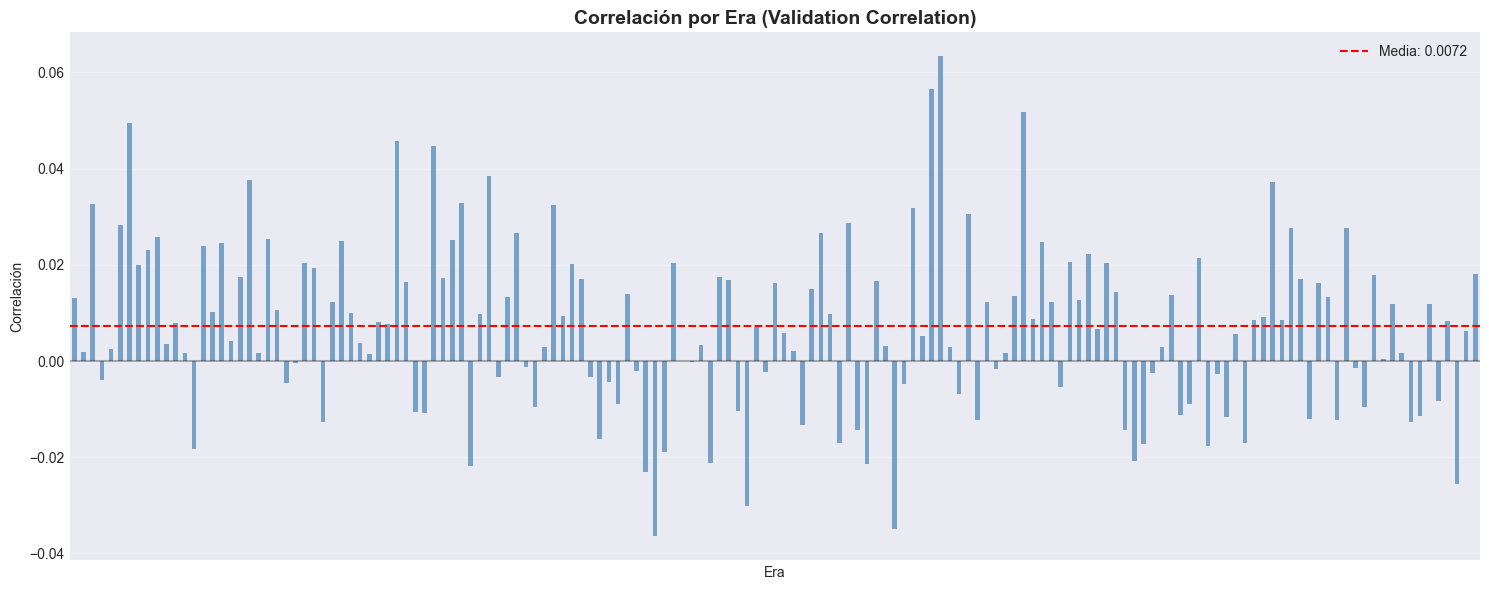

In [291]:
# Gráfica de correlación por era
plt.figure(figsize=(15, 6))
per_era_corr.plot(kind='bar', alpha=0.7, color='steelblue')
plt.axhline(y=per_era_corr.mean(), color='r', linestyle='--', label=f'Media: {per_era_corr.mean():.4f}')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Correlación por Era (Validation Correlation)', fontsize=14, fontweight='bold')
plt.xlabel('Era')
plt.ylabel('Correlación')
plt.xticks([])  # Oculta las etiquetas del eje x para mayor claridad
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 📊 Visualización: Correlación Acumulada

En lugar de observar la puntuación "corr" de cada "era", resulta útil observar la puntuación "corr" acumulativa.

Esto se denomina "backtesting" en finanzas cuantitativas, donde las personas simulan el desempeño histórico de sus estrategias de inversión. Puedes considerar este gráfico como una prueba retrospectiva del desempeño de tu modelo durante el período de validación histórica.

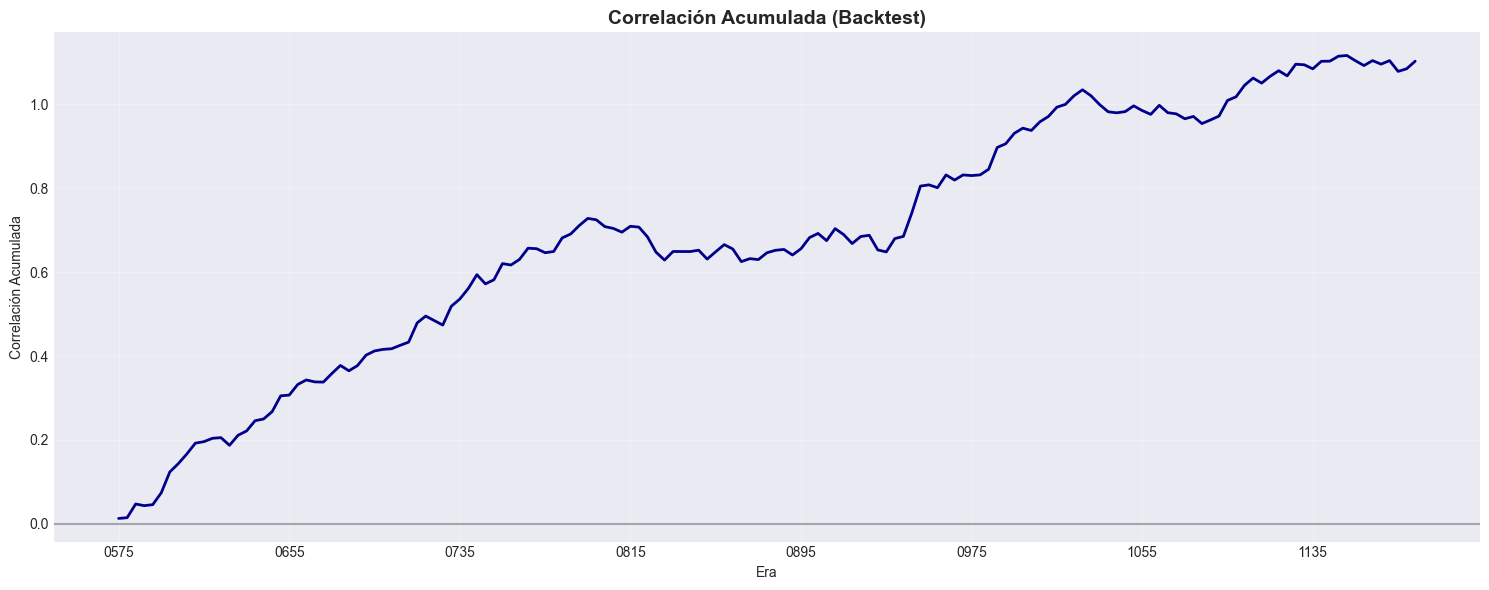


📈 Correlación final acumulada: 1.102296


In [292]:
# Correlación acumulada (backtest)
cumsum_corr = per_era_corr.cumsum()

plt.figure(figsize=(15, 6))
cumsum_corr.plot(linewidth=2, color='darkblue')
plt.title('Correlación Acumulada (Backtest)', fontsize=14, fontweight='bold')
plt.xlabel('Era')
plt.ylabel('Correlación Acumulada')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📈 Correlación final acumulada: {cumsum_corr.iloc[-1]:.6f}")

## 3.3 Métricas de Rendimiento

Para evaluar el rendimiento del modelo, también es útil calcular algunas métricas resumidas durante todo el período de validación.

**Mean**: La media de correlaciones es la medida principal del rendimiento de tu modelo.

**Sharpe**: Es una medida de la coherencia de tu modelo, un concepto tomado de las finanzas, donde generalmente se refiere a los rendimientos ajustados al riesgo de una estrategia de inversión. Aquí calcularemos Sharpe como la correlación promedio dividida por la desviación estándar de las correlaciones.

**Max Drawdown**: Es una medida del riesgo de tu modelo, otro concepto tomado de las finanzas, donde generalmente se refiere a la pérdida financiera máxima sufrida por una estrategia de inversión. Aquí calcularemos la reducción máxima como la caída máxima desde el pico hasta el mínimo en la correlación de validación acumulativa.

In [293]:
# Calcular métricas de rendimiento
print("\n📊 MÉTRICAS DE RENDIMIENTO - VALIDATION")

corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

metrics_df = pd.DataFrame({
    'Métrica': ['Mean', 'Std', 'Sharpe', 'Max Drawdown'],
    'Valor': [corr_mean, corr_std, corr_sharpe, max_drawdown]
})

print("")
print(metrics_df.to_string(index=False))



📊 MÉTRICAS DE RENDIMIENTO - VALIDATION

     Métrica    Valor
        Mean 0.007205
         Std 0.018060
      Sharpe 0.398932
Max Drawdown 0.102969


2025-11-04 23:26:49,624 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 23:26:49,625 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


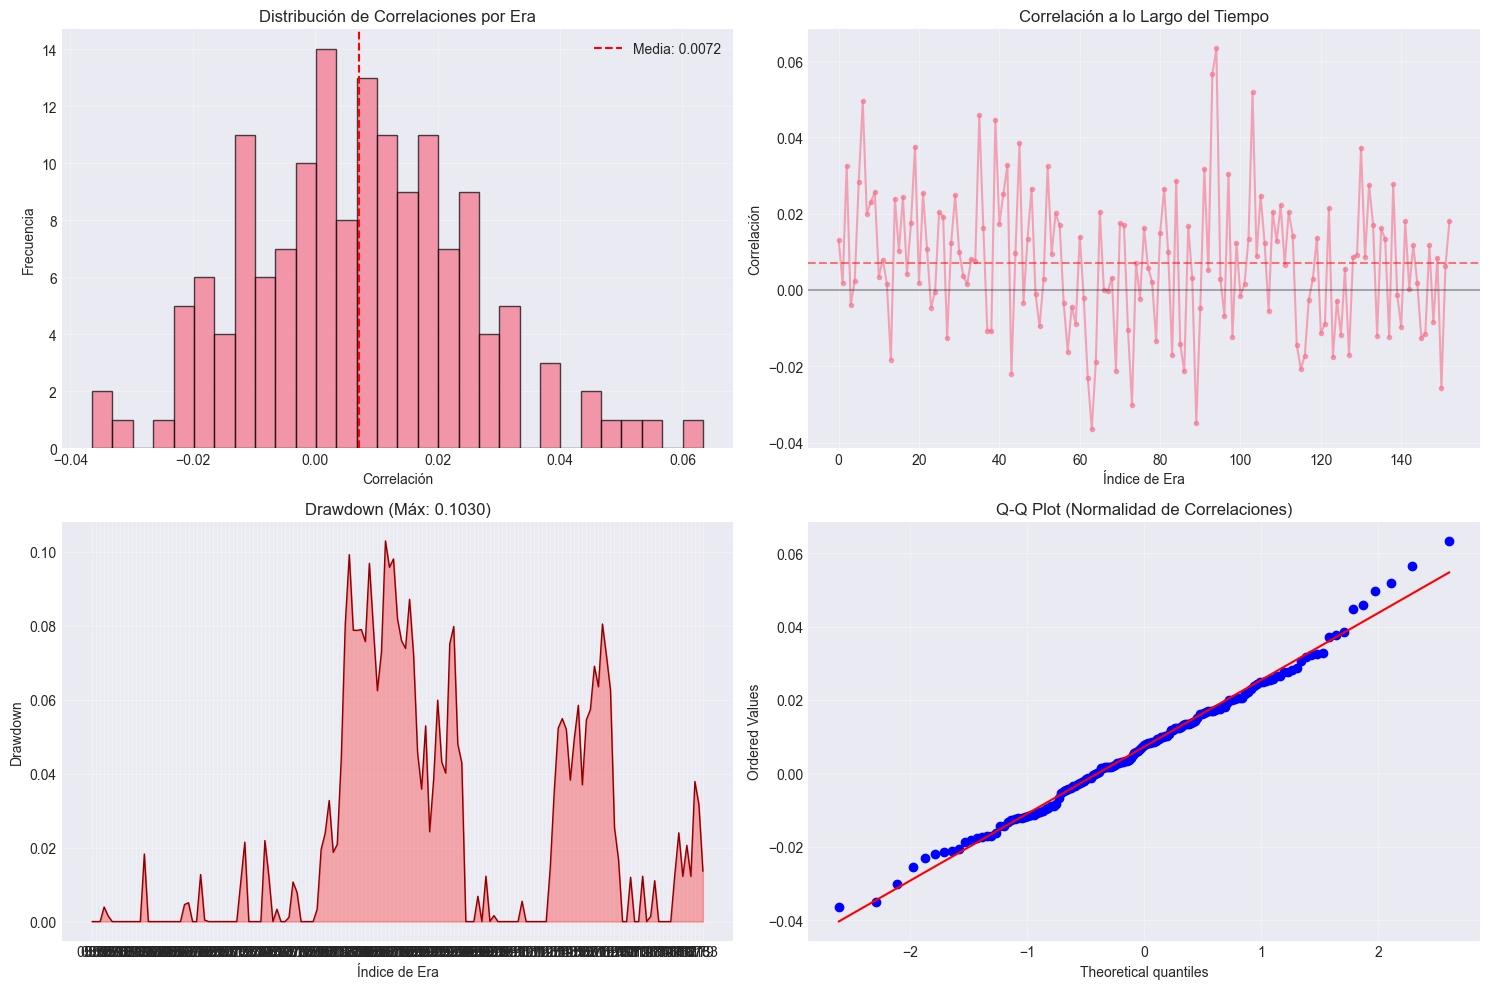

In [294]:
# Visualizar métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histograma de correlaciones
axes[0, 0].hist(per_era_corr, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(corr_mean, color='r', linestyle='--', label=f'Media: {corr_mean:.4f}')
axes[0, 0].set_title('Distribución de Correlaciones por Era')
axes[0, 0].set_xlabel('Correlación')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Correlación vs Era
axes[0, 1].plot(per_era_corr.values, marker='o', alpha=0.6, markersize=3)
axes[0, 1].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[0, 1].axhline(corr_mean, color='r', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Correlación a lo Largo del Tiempo')
axes[0, 1].set_xlabel('Índice de Era')
axes[0, 1].set_ylabel('Correlación')
axes[0, 1].grid(True, alpha=0.3)

# Drawdown
running_max = per_era_corr.cumsum().expanding(min_periods=1).max()
drawdown = running_max - per_era_corr.cumsum()
axes[1, 0].fill_between(range(len(drawdown)), drawdown, alpha=0.3, color='red')
axes[1, 0].plot(drawdown, linewidth=1, color='darkred')
axes[1, 0].set_title(f'Drawdown (Máx: {max_drawdown:.4f})')
axes[1, 0].set_xlabel('Índice de Era')
axes[1, 0].set_ylabel('Drawdown')
axes[1, 0].grid(True, alpha=0.3)

# QQ plot (normalidad)
from scipy import stats as sp_stats
sp_stats.probplot(per_era_corr, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normalidad de Correlaciones)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. IMPROVEMENT

Aplicaremos Feature Neutralization para reducir Feature Risk

In [295]:
def neutralize_predictions(predictions, features, proportion=1.0):

    # Regresión lineal
    lr = LinearRegression()
    lr.fit(features, predictions)
    
    # Predicción de la regresión
    pred_from_features = lr.predict(features)
    
    # Residuales (lo que NO explican las features)
    residuals = predictions - pred_from_features
    
    # Aplicar proporción de neutralización
    neutralized = predictions - (proportion * pred_from_features)
    
    return pd.Series(neutralized, index=predictions.index)


In [296]:
# Aplicar neutralización en validation
print("📊 PASO 4: FEATURE NEUTRALIZATION")

# Seleccionar features para neutralizar (las más correlacionadas)
top_features_to_neutralize = correlations.abs().nlargest(20).index.tolist()

# Preparar features
if USE_PCA:
    # Si usamos PCA, neutralizamos contra componentes principales
    features_for_neutralization = validation_final[pca_columns[:20]]
else:
    # Si no, contra las features más correlacionadas
    features_for_neutralization = validation_filtered[top_features_to_neutralize]

# Neutralizar
validation_final['prediction_neutralized'] = neutralize_predictions(
    validation_final['prediction'],
    features_for_neutralization,
    proportion=0.5  # Neutralización al 50%
)



📊 PASO 4: FEATURE NEUTRALIZATION


## 4.1 Comparación: Antes vs Después de Neutralización

In [297]:
# Calcular correlación por era - neutralizado
per_era_corr_neutralized = validation_final.groupby("era").apply(
    lambda x: practica_corr(x["prediction_neutralized"], x["target"])
)

# Comparar métricas
print("📊 COMPARACIÓN: ORIGINAL vs NEUTRALIZADO\n")
metrics_comparison = pd.DataFrame({
    'Métrica': ['Mean', 'Std', 'Sharpe', 'Max Drawdown'],
    'Original': [
        per_era_corr.mean(),
        per_era_corr.std(ddof=0),
        per_era_corr.mean() / per_era_corr.std(ddof=0),
        (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()
    ],
    'Neutralizado': [
        per_era_corr_neutralized.mean(),
        per_era_corr_neutralized.std(ddof=0),
        per_era_corr_neutralized.mean() / per_era_corr_neutralized.std(ddof=0),
        (per_era_corr_neutralized.cumsum().expanding(min_periods=1).max() - per_era_corr_neutralized.cumsum()).max()
    ]
})

metrics_comparison['Mejora %'] = (
    (metrics_comparison['Neutralizado'] - metrics_comparison['Original']) / 
    metrics_comparison['Original'].abs() * 100
)

print(metrics_comparison.to_string(index=False))

# Decidir cuál usar
if metrics_comparison.loc[2, 'Neutralizado'] > metrics_comparison.loc[2, 'Original']:
    print("\nLA NEUTRALIZACIÓN MEJORA EL SHARPE → Se usan predicciones neutralizadas")
    USE_NEUTRALIZED = True
else:
    print("\nLA NEUTRALIZACIÓN NO MEJORA → Se mantienen predicciones originales")
    USE_NEUTRALIZED = False

📊 COMPARACIÓN: ORIGINAL vs NEUTRALIZADO

     Métrica  Original  Neutralizado   Mejora %
        Mean  0.007205      0.006369 -11.592482
         Std  0.018060      0.017453  -3.357885
      Sharpe  0.398932      0.364940  -8.520713
Max Drawdown  0.102969      0.103256   0.278582

LA NEUTRALIZACIÓN NO MEJORA → Se mantienen predicciones originales


C:\Users\G\AppData\Local\Temp\ipykernel_23160\1281340850.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_neutralized = validation_final.groupby("era").apply(


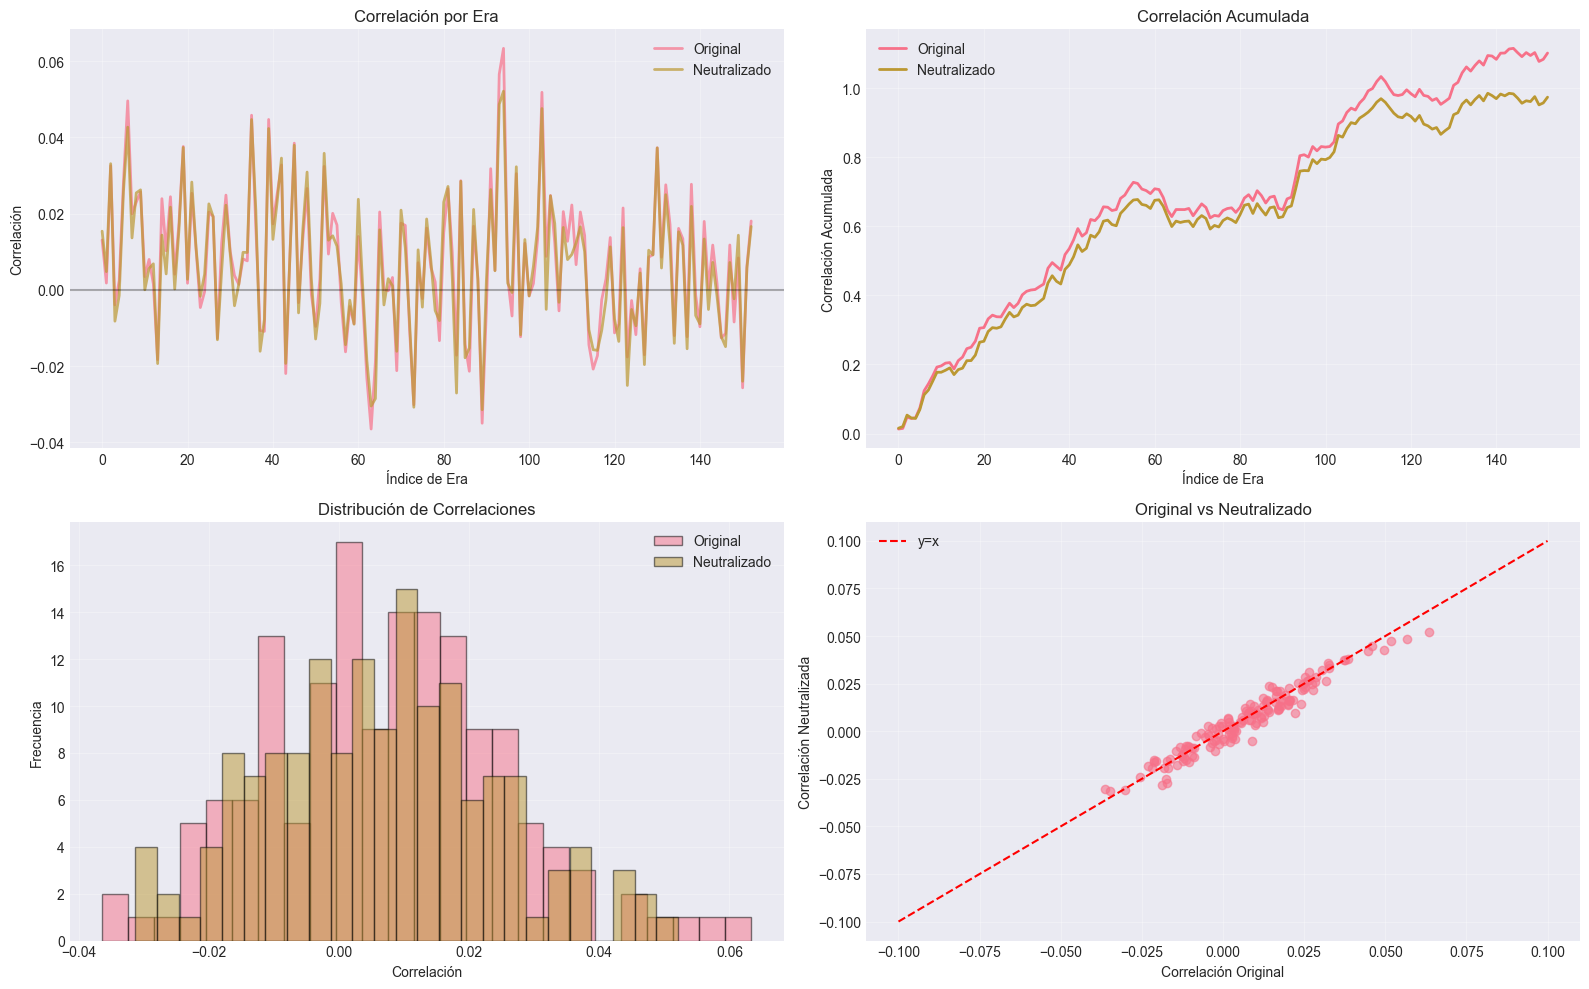

In [298]:
# Visualizar comparación
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Correlación por era
axes[0, 0].plot(per_era_corr.values, label='Original', alpha=0.7, linewidth=2)
axes[0, 0].plot(per_era_corr_neutralized.values, label='Neutralizado', alpha=0.7, linewidth=2)
axes[0, 0].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[0, 0].set_title('Correlación por Era')
axes[0, 0].set_xlabel('Índice de Era')
axes[0, 0].set_ylabel('Correlación')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Correlación acumulada
axes[0, 1].plot(per_era_corr.cumsum().values, label='Original', linewidth=2)
axes[0, 1].plot(per_era_corr_neutralized.cumsum().values, label='Neutralizado', linewidth=2)
axes[0, 1].set_title('Correlación Acumulada')
axes[0, 1].set_xlabel('Índice de Era')
axes[0, 1].set_ylabel('Correlación Acumulada')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Distribución de correlaciones
axes[1, 0].hist(per_era_corr, bins=25, alpha=0.5, label='Original', edgecolor='black')
axes[1, 0].hist(per_era_corr_neutralized, bins=25, alpha=0.5, label='Neutralizado', edgecolor='black')
axes[1, 0].set_title('Distribución de Correlaciones')
axes[1, 0].set_xlabel('Correlación')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Scatter: Original vs Neutralizado
axes[1, 1].scatter(per_era_corr, per_era_corr_neutralized, alpha=0.6)
axes[1, 1].plot([-0.1, 0.1], [-0.1, 0.1], 'r--', label='y=x')
axes[1, 1].set_title('Original vs Neutralizado')
axes[1, 1].set_xlabel('Correlación Original')
axes[1, 1].set_ylabel('Correlación Neutralizada')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.2 Explicación del Resultado

- Las features originales ya eran robustas
- El modelo captura patrones fundamentales
- No había un feature risk significativo

# 5. SUBMISSION

Evaluación de los modelos según su rendimiento en vivo

Generación de predicciones en datos en vivo y serialización del modelo.

## 5.1 Descarga de Datos Live

In [299]:
# Descargar live data
live_file = f"{DATA_VERSION}/live.parquet"

live = pd.read_parquet(
    live_file,
    columns=feature_set
)

print(f"Live data cargado: {live.shape}")

Live data cargado: (6852, 705)


## 5.2 Preprocesar Live Data

In [300]:
# Aplicar mismo pipeline

# Filtrar features
live_filtered = live[selected_features].copy()

# Escalar
live_scaled = scaler.transform(live_filtered)

# PCA si corresponde
if USE_PCA:
    live_pca = pca.transform(live_scaled)
    live_final = pd.DataFrame(live_pca, columns=pca_columns, index=live.index)
else:
    live_final = pd.DataFrame(live_scaled, columns=selected_features, index=live.index)


C:\Users\G\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


## 5.3 Generar Predicciones

In [301]:
# Generar predicciones en vivo

live_predictions = final_model.predict(live_final[FINAL_FEATURES])

# Neutralizar si corresponde
if USE_NEUTRALIZED:
    if USE_PCA:
        features_for_neutralization_live = live_final[pca_columns[:20]]
    else:
        features_for_neutralization_live = live_filtered[top_features_to_neutralize]
    
    live_predictions = neutralize_predictions(
        pd.Series(live_predictions, index=live.index),
        features_for_neutralization_live,
        proportion=0.5
    ).values

# Crear submission
submission = pd.DataFrame({
    'prediction': live_predictions
}, index=live.index)

print(f"\n  Predicciones generadas: {len(submission)}")
print(f"\n📊 ESTADÍSTICAS DE PREDICCIONES:")
print(submission['prediction'].describe())

# También mostrar primeras predicciones
print("\n PRIMERAS 10 PREDICCIONES:")
print(submission.head(10))


  Predicciones generadas: 6852

📊 ESTADÍSTICAS DE PREDICCIONES:
count    6852.000000
mean        0.500026
std         0.007086
min         0.472900
25%         0.495185
50%         0.500111
75%         0.504895
max         0.521738
Name: prediction, dtype: float64

 PRIMERAS 10 PREDICCIONES:
                  prediction
id                          
n001b5cc671480f8    0.500698
n001e484d6a60cde    0.504230
n002a862c140978e    0.492758
n0033096bae8eb9a    0.506431
n004ec27fa53f292    0.491575
n005352728e3f45a    0.496053
n005542ef791d5bd    0.503664
n005e22b3a684cf2    0.494441
n007153550afb0ff    0.504516
n00841ab86d3b0e8    0.490145


## 5.4 Serialización del Modelo con cloudpickle

**¿Por qué cloudpickle?**
- Serializa objetos complejos
- Funciona con lambdas y closures
- Más robusto que pickle estándar

In [302]:
# Crear objeto con todo lo necesario

model_artifact = {
    'model': final_model,
    'scaler': scaler,
    'selected_features': selected_features,
    'use_pca': USE_PCA,
    'pca': pca if USE_PCA else None,
    'pca_columns': pca_columns if USE_PCA else None,
    'final_features': FINAL_FEATURES,
    'use_neutralized': USE_NEUTRALIZED,
    'top_features_to_neutralize': top_features_to_neutralize if USE_NEUTRALIZED else None,
    'metadata': {
        'fecha_creacion': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'modelo': best_model_name,
        'corr_validation': corr_mean,
        'sharpe': corr_sharpe,
        'n_features': len(FINAL_FEATURES)
    }
}

# Guardar
with open('modelo_numerai.pkl', 'wb') as f:
    cloudpickle.dump(model_artifact, f)

print("  Modelo serializado: modelo_numerai.pkl")
print(f"  Tamaño: {os.path.getsize('modelo_numerai.pkl') / 1024**2:.2f} MB")

  Modelo serializado: modelo_numerai.pkl
  Tamaño: 0.02 MB


## 5.5 Función de Predicción para Producción

In [303]:
def predict_live(live_data, model_path='modelo_numerai.pkl'):

    import cloudpickle
    import pandas as pd
    from sklearn.linear_model import LinearRegression
    
    # Cargar modelo
    with open(model_path, 'rb') as f:
        artifact = cloudpickle.load(f)
    
    # Extraer componentes
    model = artifact['model']
    scaler = artifact['scaler']
    selected_features = artifact['selected_features']
    use_pca = artifact['use_pca']
    pca = artifact['pca']
    final_features = artifact['final_features']
    use_neutralized = artifact['use_neutralized']
    
    # Preprocesar
    live_filtered = live_data[selected_features].copy()
    live_scaled = scaler.transform(live_filtered)
    
    if use_pca:
        live_pca = pca.transform(live_scaled)
        live_final = pd.DataFrame(live_pca, columns=artifact['pca_columns'], index=live_data.index)
    else:
        live_final = pd.DataFrame(live_scaled, columns=selected_features, index=live_data.index)
    
    # Predecir
    predictions = model.predict(live_final[final_features])
    
    # Neutralizar si corresponde
    if use_neutralized:
        if use_pca:
            feats = live_final[artifact['pca_columns'][:20]]
        else:
            feats = live_filtered[artifact['top_features_to_neutralize']]
        
        lr = LinearRegression()
        lr.fit(feats, predictions)
        pred_from_features = lr.predict(feats)
        predictions = predictions - (0.5 * pred_from_features)
    
    return pd.DataFrame({'prediction': predictions}, index=live_data.index)



## 5.6 Validar Carga del Modelo

In [304]:
# Probar carga

with open('modelo_numerai.pkl', 'rb') as f:
    loaded_artifact = cloudpickle.load(f)

print("\n  MODELO CARGADO CORRECTAMENTE")
print("\n📋 METADATA:")
for key, value in loaded_artifact['metadata'].items():
    print(f"  {key}: {value}")


  MODELO CARGADO CORRECTAMENTE

📋 METADATA:
  fecha_creacion: 2025-11-04 23:26:51
  modelo: Ridge
  corr_validation: 0.007204549951675885
  sharpe: 0.39893151195872645
  n_features: 31


In [305]:
# Probar función de predicción

test_predictions = predict_live(live, 'modelo_numerai.pkl')

print("\n  FUNCIÓN DE PREDICCIÓN FUNCIONA")
print(f"  Predicciones generadas: {len(test_predictions)}")
print(f"  Match con submission: {(test_predictions['prediction'] == submission['prediction']).sum() / len(submission) * 100:.1f}%")


  FUNCIÓN DE PREDICCIÓN FUNCIONA
  Predicciones generadas: 6852
  Match con submission: 100.0%


C:\Users\G\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


## 5.7 Guardar Submission

In [306]:
# Guardar submission para envío
submission_filename = f'submission_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
submission.to_csv(submission_filename)

print(f"\n  SUBMISSION GUARDADO: {submission_filename}")
print(f"  Formato: CSV con índice (id) y columna 'prediction'")
print(f"  Listo para subir a Numerai")

# Envío - Formato compatible con Numerai
submission


  SUBMISSION GUARDADO: submission_20251104_232651.csv
  Formato: CSV con índice (id) y columna 'prediction'
  Listo para subir a Numerai


,prediction
id,
n001b5cc671480f8,0.500698
n001e484d6a60cde,0.504230
n002a862c140978e,0.492758
n0033096bae8eb9a,0.506431
n004ec27fa53f292,0.491575
...,...
nffd60ecda65f998,0.511338
nffde21be9bf1258,0.489235
nffdec906fde9863,0.503008
